## Refraction

### Snell's Law
Snell's law relates the angle of incidence $\alpha$ and the angle of refraction $\beta$ through

$$n_A \sin(\alpha) = n \sin(\beta).$$

Since the refractive index of air is approximately $n_A \approx 1$, this becomes

$$\sin(\alpha) = n \sin(\beta),$$

where $n$ is the refractive index of the glass prism relative to air.

#### Graphing $\sin\alpha$ vs. $\sin\beta$
If we plot $y = \sin(\alpha)$ against $x = \sin(\beta)$, the formula becomes
$$y = n x,$$
We thus expect to get a linear function whose slope ($y' = (n x)'$) is the refractive index ($(n x)' = n$).

The uncertainty of the sine values is obtained by Gaussian error propagation,

$$d(\sin\theta) = |\cos\theta| \, d\theta,$$

with the angular uncertainty expressed in radians.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.odr import Model, ODR, RealData

# Enter the measured angles in degrees.
alpha = np.array([60, 39, 21, 7, 13.5, 32.5, 47.5, 27])  # angle of incidence
beta = np.array([37, 26, 14, 5, 11.5, 21, 31, 19])   # angle of refraction

dalpha = 2.0  # uncertainty of alpha in degrees
dbeta = 2.0   # uncertainty of beta in degrees

def require_data(*arrays):
    if any(np.size(arr) == 0 for arr in arrays):
        raise ValueError('Enter your measured data in the arrays before running the analysis cells.')

def line_through_origin(x, m):
    return m * x

def odr_line_through_origin(beta, x):
    return beta[0] * x

def constant_model(x, c):
    x = np.asarray(x)
    return np.full_like(x, c, dtype=float)

def displacement_model(alpha_deg, n, width_cm):
    alpha_rad = np.deg2rad(alpha_deg)
    beta_rad = np.arcsin(np.clip(np.sin(alpha_rad) / n, -1, 1))
    return width_cm * np.sin(alpha_rad - beta_rad) / np.cos(beta_rad)

require_data(alpha, beta)

if alpha.shape != beta.shape:
    raise ValueError('alpha and beta must have the same length.')

alpha_rad = np.deg2rad(alpha)
beta_rad = np.deg2rad(beta)
dalpha_rad = np.deg2rad(dalpha)
dbeta_rad = np.deg2rad(dbeta)

sin_alpha = np.sin(alpha_rad)
sin_beta = np.sin(beta_rad)
dsin_alpha = np.abs(np.cos(alpha_rad)) * dalpha_rad
dsin_beta = np.abs(np.cos(beta_rad)) * dbeta_rad

n_point = sin_alpha / sin_beta
dn_point = n_point * np.sqrt((dsin_alpha / sin_alpha)**2 + (dsin_beta / sin_beta)**2)


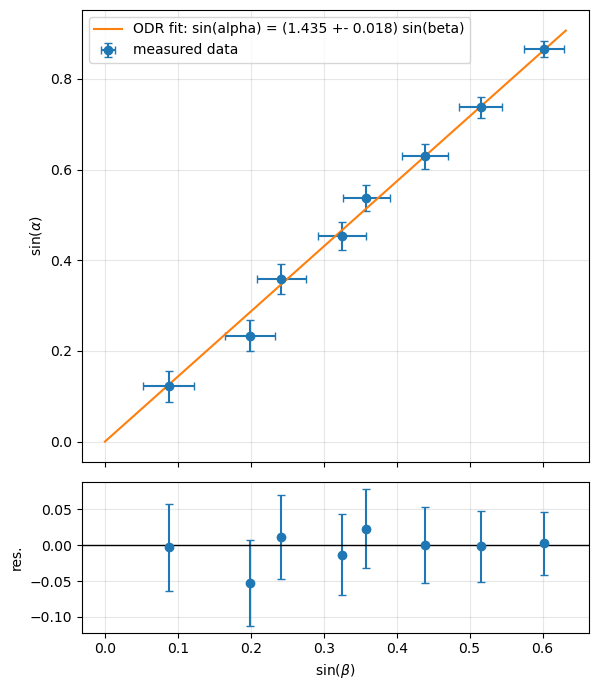

In [16]:
sin_data = RealData(sin_beta, sin_alpha, sx=dsin_beta, sy=dsin_alpha)
sin_model = Model(odr_line_through_origin)
sin_odr = ODR(sin_data, sin_model, beta0=[1.5])
sin_output = sin_odr.run()

n_sin = sin_output.beta[0]
dn_sin = sin_output.sd_beta[0]

sin_beta_fit = np.linspace(0, 1.05 * np.max(sin_beta), 300)
sin_alpha_fit = line_through_origin(sin_beta_fit, n_sin)
residuals_sin = sin_alpha - line_through_origin(sin_beta, n_sin)
dresiduals_sin = np.sqrt(dsin_alpha**2 + (n_sin * dsin_beta)**2)

fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(6, 7), sharex=True, height_ratios=(3, 1))
ax.errorbar(sin_beta, sin_alpha, xerr=dsin_beta, yerr=dsin_alpha, fmt='o', capsize=3, label='measured data')
ax.plot(sin_beta_fit, sin_alpha_fit, label=f'ODR fit: sin(alpha) = ({n_sin:.3f} +- {dn_sin:.3f}) sin(beta)')
ax.set_ylabel(r'$\sin(\alpha)$')
ax.legend()
ax.grid(True, alpha=0.3)

ax_res.errorbar(sin_beta, residuals_sin, yerr=dresiduals_sin, fmt='o', capsize=3)
ax_res.axhline(0, color='black', linewidth=1)
ax_res.set_xlabel(r'$\sin(\beta)$')
ax_res.set_ylabel('res.')
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Refractive Index
From Snell's law in the form $\sin(\alpha) = n \sin(\beta)$, the slope of the graph $\sin(\alpha)$ vs. $\sin(\beta)$ is directly equal to the refractive index $n$ of the material relative to air. We expect a value larger than 1 as the prism is an optically denser medium.

In [17]:
print(f'Refractive index: n = {n_sin:.3f} +- {dn_sin:.3f}')

Refractive index: n = 1.435 +- 0.018


#### Graphing $n$ vs. $\alpha$

For each measured angle pair, Snell's law gives an individual estimate of the refractive index,

$$n_i = \frac{\sin(\alpha_i)}{\sin(\beta_i)}.$$

If the model is correct, these values should be independent of the incoming angle. Therefore $n$ is plotted against $\alpha$ and fitted with a constant. This fit parameter can then be compared with the slope obtained in part a).

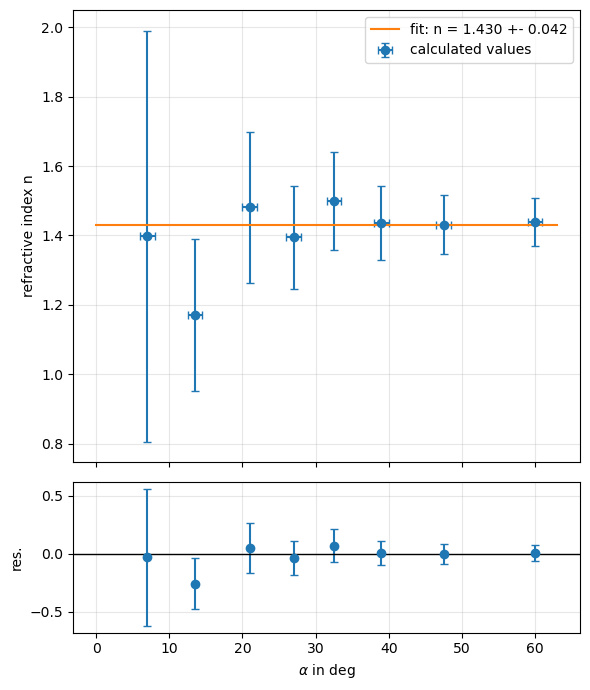

In [4]:
popt_n, pcov_n = curve_fit(
    constant_model,
    alpha,
    n_point,
    sigma=dn_point,
    absolute_sigma=True,
)
n_const = popt_n[0]
dn_const = np.sqrt(np.diag(pcov_n))[0]

alpha_fit = np.linspace(0, 1.05 * np.max(alpha), 300)
n_fit = constant_model(alpha_fit, n_const)
residuals_n = n_point - constant_model(alpha, n_const)

fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(6, 7), sharex=True, height_ratios=(3, 1))
ax.errorbar(alpha, n_point, xerr=dalpha, yerr=dn_point, fmt='o', capsize=3, label='calculated values')
ax.plot(alpha_fit, n_fit, label=f'fit: n = {n_const:.3f} +- {dn_const:.3f}')
ax.set_ylabel('refractive index n')
ax.legend()
ax.grid(True, alpha=0.3)

ax_res.errorbar(alpha, residuals_n, yerr=dn_point, fmt='o', capsize=3)
ax_res.axhline(0, color='black', linewidth=1)
ax_res.set_xlabel(r'$\alpha$ in deg')
ax_res.set_ylabel('res.')
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Refractive Index
In this graph the fit parameter is again the refractive index itself, now obtained as the best constant value describing the individually calculated values $n_i = \sin(\alpha_i)/\sin(\beta_i)$. Within uncertainty it should agree with the result from the linear sine graph in part a).

In [5]:
print(f'Refractive index from the n-vs-alpha graph: n = {n_const:.3f} +- {dn_const:.3f}')
print(f'Difference to part a): Delta n = {n_const - n_sin:.3f}')

Refractive index from the n-vs-alpha graph: n = 1.430 +- 0.042
Difference to part a): Delta n = -0.006


#### Discussion
The fit in part a) tests Snell's law in its linearized form and should therefore usually provide the clearest estimate of the refractive index. If the residuals are randomly distributed around zero with no visible trend, the linear model is consistent with the data. In part b), the calculated values of $n$ should scatter around a constant value with no systematic dependence on $\alpha$. A visible trend in the residuals would indicate a systematic problem such as angle-reading errors, imperfect alignment of the normal, or a small offset in the protractor reading. The two fit parameters should agree within uncertainty; if they do, this supports both the data quality and the validity of Snell's law for the prism.

#### Parallel displacement
For a plane-parallel prism or glass block of width $w$, the emergent ray is parallel to the incident ray but shifted sideways by a distance $s$. From the ray geometry one obtains

$$s = \frac{w \, \sin(\alpha - \beta)}{\cos(\beta)}.$$

Using Snell's law with $n_A \approx 1$,

$$\beta = \arcsin\left(\frac{\sin(\alpha)}{n}\right),$$

so the displacement as a function of incoming angle $\alpha$, refractive index $n$, and prism width $w$ is

$$s(\alpha, n, w) = \frac{w \, \sin\!\left(\alpha - \arcsin(\sin(\alpha)/n)\right)}{\cos\!\left(\arcsin(\sin(\alpha)/n)\right)}.$$

For one selected measurement point, the predicted displacement and its absolute uncertainty are calculated below using Gaussian uncertainty propagation.

In [6]:
# Enter the measurements for the parallel displacement here.
alpha_shift = alpha  # angle of incidence in degrees
shift = np.array([2.5, 1.25, 0.567, 0.25, 0.6, 1.1, 2.6, 0.9])         # parallel displacement in cm
dshift = 0.1                # uncertainty of the displacement in cm

# Width of the prism / glass block in cm.
w = 0.0
dw = 0.1

# Index of the data point for the explicit prediction.
point_index = 0

require_data(alpha_shift, shift)

if alpha_shift.shape != shift.shape:
    raise ValueError('alpha_shift and shift must have the same length.')
if w <= 0:
    raise ValueError('Enter the prism width in the variable w.')
if not (0 <= point_index < len(alpha_shift)):
    raise ValueError('point_index is outside the valid range.')

alpha_shift_fit = np.linspace(0, 1.05 * np.max(alpha_shift), 300)
shift_theory = displacement_model(alpha_shift_fit, n_sin, w)
shift_residuals = shift - displacement_model(alpha_shift, n_sin, w)

fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(6, 7), sharex=True, height_ratios=(3, 1))
ax.errorbar(alpha_shift, shift, xerr=dalpha, yerr=dshift, fmt='o', capsize=3, label='measured data')
ax.plot(alpha_shift_fit, shift_theory, label=f'theory with n = {n_sin:.3f} and w = {w:.2f} cm')
ax.set_ylabel('shift in cm')
ax.legend()
ax.grid(True, alpha=0.3)

ax_res.errorbar(alpha_shift, shift_residuals, yerr=dshift, fmt='o', capsize=3)
ax_res.axhline(0, color='black', linewidth=1)
ax_res.set_xlabel(r'$\alpha$ in deg')
ax_res.set_ylabel('res. / cm')
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

alpha0 = alpha_shift[point_index]
alpha0_rad = np.deg2rad(alpha0)
beta0_rad = np.arcsin(np.clip(np.sin(alpha0_rad) / n_sin, -1, 1))
s0 = displacement_model(alpha0, n_sin, w)

# Numerical partial derivatives for Gaussian error propagation.
h_alpha = max(np.deg2rad(dalpha), 1e-6)
h_n = max(dn_sin, 1e-6)
h_w = max(dw, 1e-6)

def displacement_rad(alpha_rad, n, width_cm):
    beta_rad = np.arcsin(np.clip(np.sin(alpha_rad) / n, -1, 1))
    return width_cm * np.sin(alpha_rad - beta_rad) / np.cos(beta_rad)

ds_dalpha = (displacement_rad(alpha0_rad + h_alpha, n_sin, w) - displacement_rad(alpha0_rad - h_alpha, n_sin, w)) / (2 * h_alpha)
ds_dn = (displacement_rad(alpha0_rad, n_sin + h_n, w) - displacement_rad(alpha0_rad, n_sin - h_n, w)) / (2 * h_n)
ds_dw = (displacement_rad(alpha0_rad, n_sin, w + h_w) - displacement_rad(alpha0_rad, n_sin, w - h_w)) / (2 * h_w)

ds0 = np.sqrt((ds_dalpha * np.deg2rad(dalpha))**2 + (ds_dn * dn_sin)**2 + (ds_dw * dw)**2)
difference = shift[point_index] - s0
ddifference = np.sqrt(dshift**2 + ds0**2)

print(f'Predicted displacement for point {point_index}: s = {s0:.3f} +- {ds0:.3f} cm')
print(f'Measured displacement for point {point_index}: s_meas = {shift[point_index]:.3f} +- {dshift:.3f} cm')
print(f'Difference: Delta s = {difference:.3f} +- {ddifference:.3f} cm')

ValueError: Enter the prism width in the variable w.

#### Discussion
The parallel displacement should increase with the incoming angle because the light travels a longer oblique path through the prism before emerging. The theoretical curve uses the refractive index from part a), so agreement with the measured displacement is an additional consistency check for the whole analysis. If the predicted and measured values for the selected point agree within the combined uncertainty, the result is consistent with the geometrical model. Any larger discrepancy would most likely come from reading the lateral displacement less precisely than the angles, from uncertainty in the prism width $w$, or from slight misalignment when tracing the rays.